##SALES FORECASTING

In [ ]:
##IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

print("Libraries imported successfully!")

In [ ]:
##LOAD DATASET
df_clean = pd.read_csv("../data/raw/superstore.csv", encoding="cp1252")

print("Data loaded successfully!")

In [ ]:
##DATA EXPLORATION
df_clean.head()

In [ ]:
##SHAPE OF DATASET
df_clean.shape

In [ ]:
##COLUMNS OF DATASET
df_clean.columns.tolist()

In [7]:
##CONVERT ORDER DATE
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])

In [ ]:
##CHECKING THE ORDER DATE DATA TYPE
df_clean["Order Date"].dtype

### TIME SERIES FORECASTING PROBLEM
The model will predict total monthly sales
so the model will aggregate monthly sales using time and sales and predicts the future time and future sales

In [9]:
##CREATING MONTHLY SALES DATASET
monthly_sales = (
    df_clean
    .set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
    .reset_index()
)

In [ ]:
##CHECKING MONTHLY SALES
monthly_sales.head()

In [ ]:
monthly_sales.shape

In [12]:
##RENAMING COLUMNS
monthly_sales.columns = ["Date", "Sales"]

In [ ]:
monthly_sales.head()

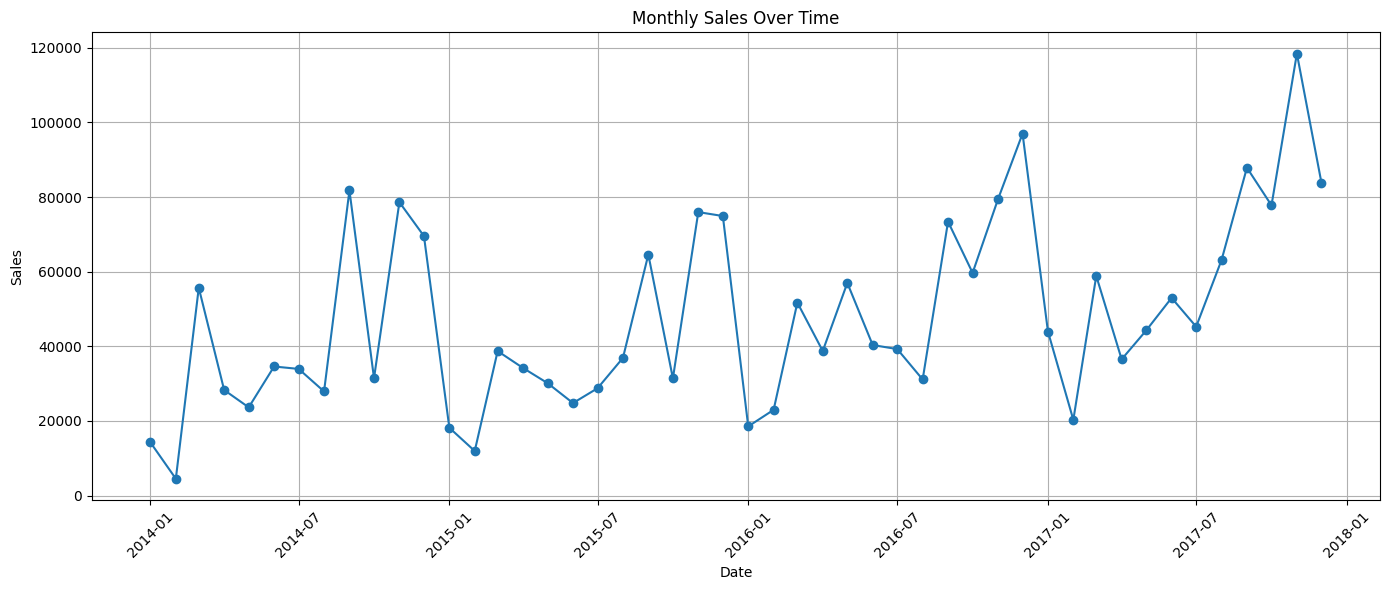

In [14]:
##PLOTTING THE SALES TIME SERIES GRAPH
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Over Time")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

### Insight

A. There appears to be an upward trend

The later years generally have higher sales than the earlier years.

For example, the largest values occur toward the end of the dataset, with a peak around $118,000.

So the series isn't stationary around one fixed sales level.

B. There is substantial month-to-month variation

You have some very large changes:
~$20k → ~$60k
~$40k → ~$97k
~$78k → ~$118k

So a model needs to handle fairly large fluctuations.

C. There appears to be seasonal behaviour

There are recurring periods of high and low sales across the years.

That's important because we're working with monthly data.

This suggests that a model capable of handling:

trend + seasonality

is a good next candidate.

In [15]:
##DECOMPOSING THE TIME SERIES
monthly_series = monthly_sales.set_index("Date")["Sales"]
decomposition = seasonal_decompose(
    monthly_series,
    model="additive",
    period=12
)

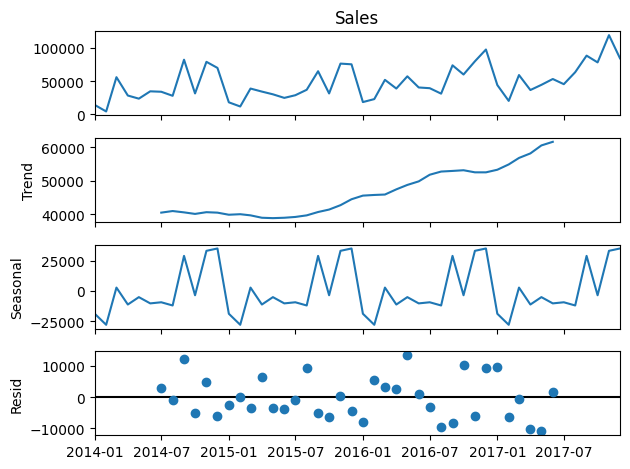

In [16]:
decomposition.plot()

plt.tight_layout()

plt.show()

Conceptually
Sales
 =
Trend
 +
Seasonality
 +
Residual

In [ ]:
##MACHINE LEARNING
##TRAIN DATASET

train = monthly_sales.iloc[:-12].copy()

test = monthly_sales.iloc[-12:].copy()

In [18]:
print("Training observations:", len(train))

print("Testing observations:", len(test))

Training observations: 36
Testing observations: 12


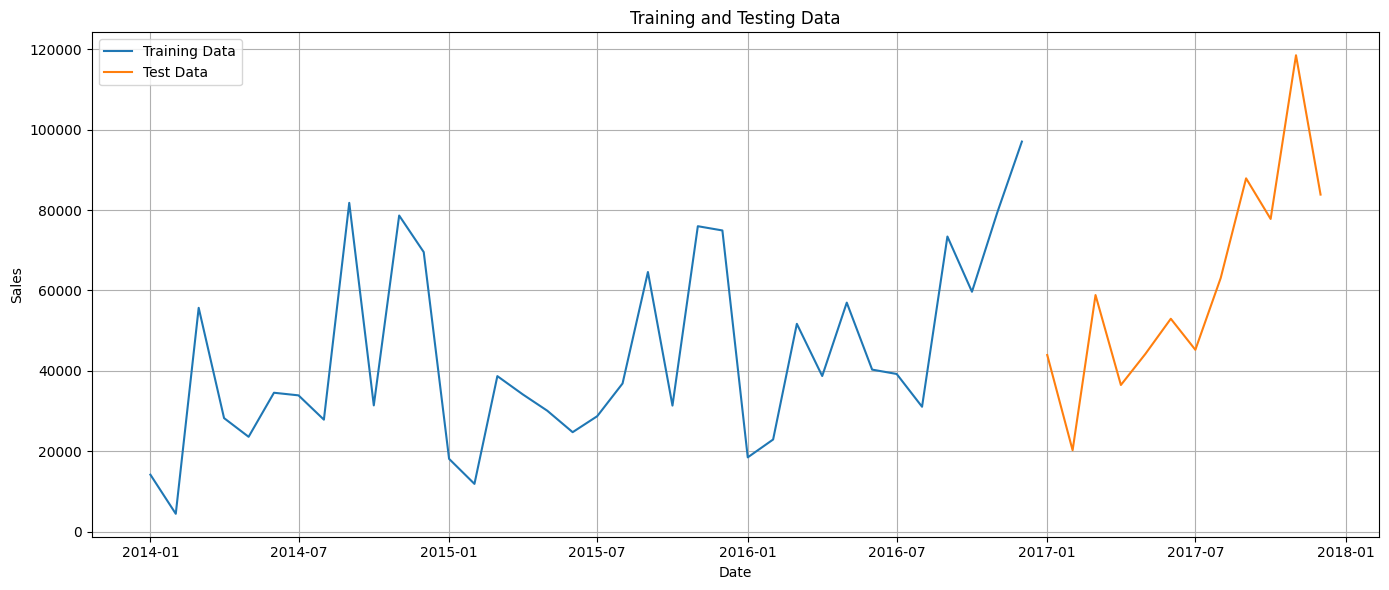

In [19]:
##PLOTTING TRAIN AND TEST

plt.figure(figsize=(14, 6))

plt.plot(
    train["Date"],
    train["Sales"],
    label="Training Data"
)

plt.plot(
    test["Date"],
    test["Sales"],
    label="Test Data"
)

plt.title("Training and Testing Data")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [20]:
##ESTABLISHING A BASELINE
test["Baseline_Prediction"] = train["Sales"].iloc[-1]

In [21]:
##USING PREVIOUS MONTH SALES AS BASELINE PREDICTIONS
baseline_predictions = monthly_sales["Sales"].shift(1)

baseline_predictions = baseline_predictions.loc[
    test.index
]

In [ ]:
##CALCULATIONS
mae_baseline = mean_absolute_error(
    test["Sales"],
    baseline_predictions
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        test["Sales"],
        baseline_predictions
    )
)

print("Baseline MAE:", mae_baseline)

print("Baseline RMSE:", rmse_baseline)

In [ ]:
##time-series versions:
train_series = train.set_index("Date")["Sales"]

test_series = test.set_index("Date")["Sales"]

In [ ]:
train_series.head()

In [29]:
##BUILDING OUR FIRST HOLT-WINTERS MODEL

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
##CREATING THE MODEL

holt_winters_model = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)


In [31]:
holt_winters_fit = holt_winters_model.fit(
    optimized=True
)

In [ ]:
##GENERATING PREDICTIONS FOR THE 12 MONTHS OF TEST DATA
holt_winters_predictions = holt_winters_fit.forecast(
    steps=len(test_series)
)

print(holt_winters_predictions)

In [33]:
##CALCULATING MAE AND RMSE FOR HOLT-WINTERS MODEL
mae_hw = mean_absolute_error(
    test_series,
    holt_winters_predictions
)

rmse_hw = np.sqrt(
    mean_squared_error(
        test_series,
        holt_winters_predictions
    )
)


In [ ]:
print("Holt-Winters MAE:", mae_hw)

print("Holt-Winters RMSE:", rmse_hw)

In [ ]:
##COMPARING THIS WITH MY BASELINE MODEL
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Holt-Winters"
    ],

    "MAE": [
        mae_baseline,
        mae_hw
    ],

    "RMSE": [
        rmse_baseline,
        rmse_hw
    ]
})

comparison

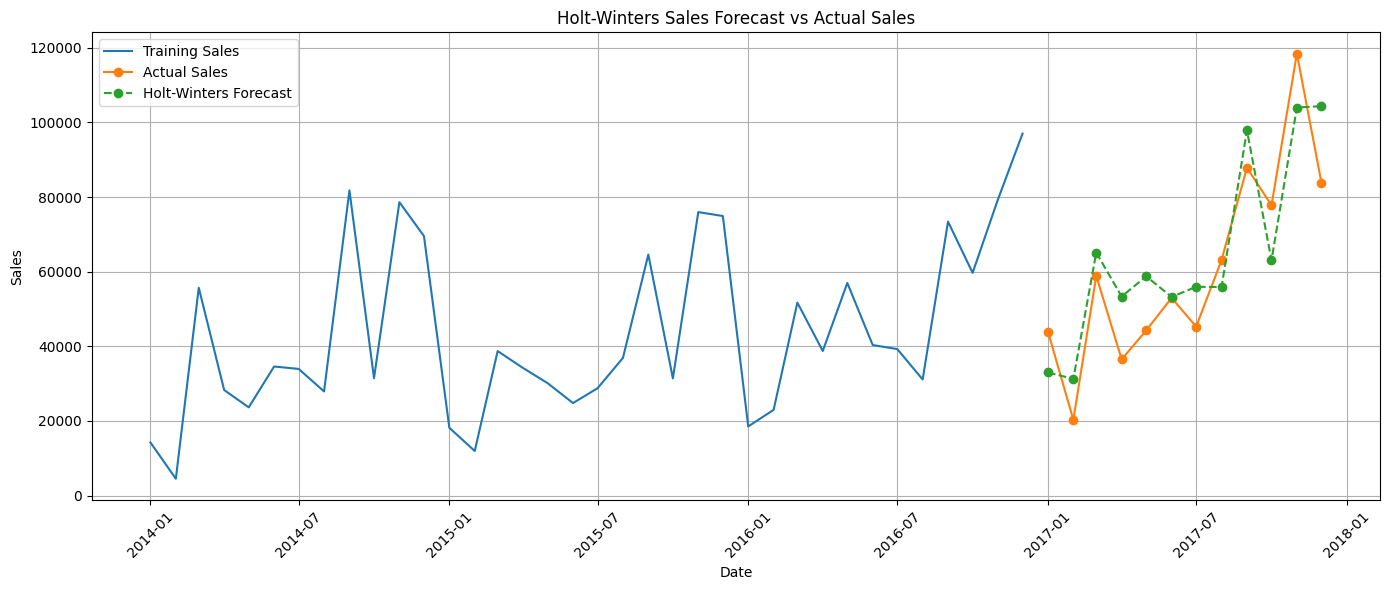

In [36]:
##PLOTTING ACTUAL VS PREDICTED SALES
plt.figure(figsize=(14, 6))

plt.plot(
    train_series.index,
    train_series,
    label="Training Sales"
)

plt.plot(
    test_series.index,
    test_series,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    holt_winters_predictions.index,
    holt_winters_predictions,
    marker="o",
    linestyle="--",
    label="Holt-Winters Forecast"
)

plt.title("Holt-Winters Sales Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
##TWO HOLT WINTERS VERSIONS
##MODEL A- ADDITIVE SEASONALITY

hw_additive = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

pred_additive = hw_additive.forecast(
    len(test_series)
)

In [ ]:
mae_additive = mean_absolute_error(
    test_series,
    pred_additive
)

rmse_additive = np.sqrt(
    mean_squared_error(
        test_series,
        pred_additive
    )
)

print("Additive MAE:", mae_additive)
print("Additive RMSE:", rmse_additive)

In [ ]:
##MULTIPLICATIVE SEASONALITY
hw_multiplicative = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit()

pred_multiplicative = hw_multiplicative.forecast(
    len(test_series)
)

In [ ]:
mae_multiplicative = mean_absolute_error(
    test_series,
    pred_multiplicative
)

rmse_multiplicative = np.sqrt(
    mean_squared_error(
        test_series,
        pred_multiplicative
    )
)

print(
    "Multiplicative MAE:",
    mae_multiplicative
)

print(
    "Multiplicative RMSE:",
    rmse_multiplicative
)

In [ ]:
##CREATING OUR FIRST PROPER MODEL COMPARISON
model_comparison = pd.DataFrame({

    "Model": [
        "Naive Baseline",
        "Holt-Winters Additive",
        "Holt-Winters Multiplicative"
    ],

    "MAE": [
        mae_baseline,
        mae_additive,
        mae_multiplicative
    ],

    "RMSE": [
        rmse_baseline,
        rmse_additive,
        rmse_multiplicative
    ]

})

model_comparison

In [42]:
##IMPORTING SARIMA MODEL
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
##BUILDING OUR FIRST SARIMA MODEL
sarima_model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

In [ ]:
##FORECASTING THE 12 MONTHS TEST PERIOD
sarima_predictions = sarima_fit.forecast(
    steps=len(test_series)
)

print(sarima_predictions)

In [ ]:
##EVALUATING SARIMA MODEL PERFORMANCE
mae_sarima = mean_absolute_error(
    test_series,
    sarima_predictions
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        test_series,
        sarima_predictions
    )
)

print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)

In [46]:
##ADDING MAPE
def mean_absolute_percentage_error(actual, predicted):

    actual = np.array(actual)
    predicted = np.array(predicted)

    return np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

  

In [ ]:
mape_sarima = mean_absolute_percentage_error(
    test_series,
    sarima_predictions
)

print("SARIMA MAPE:", mape_sarima)

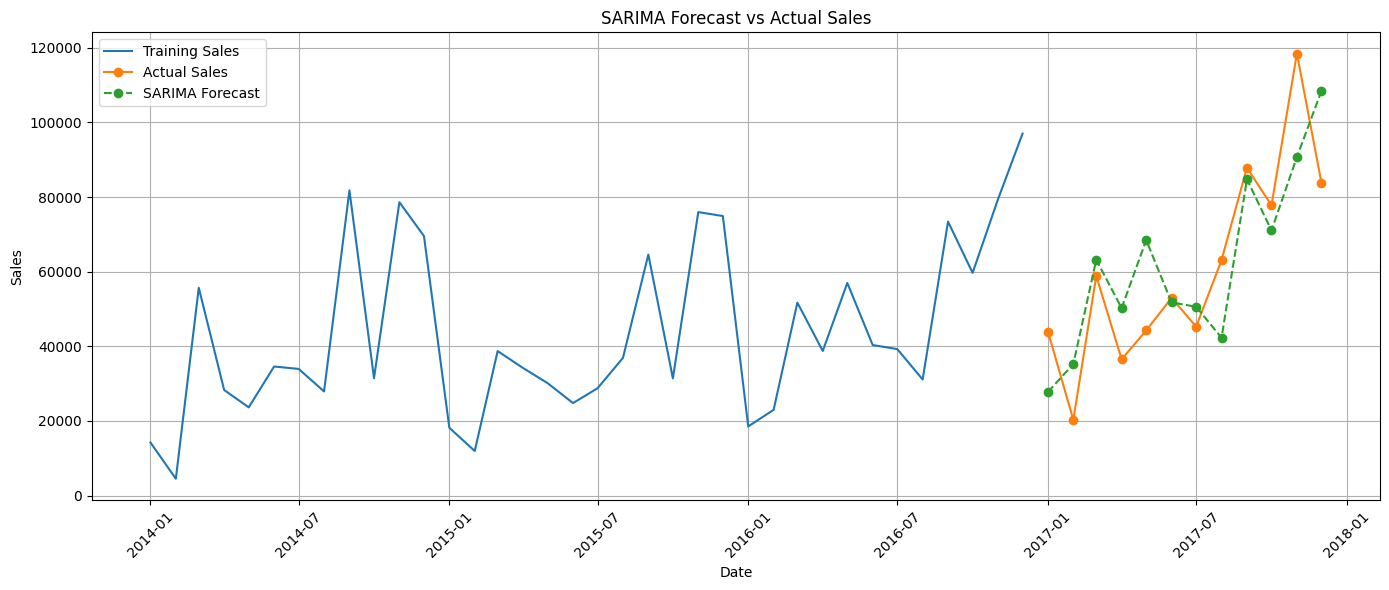

In [48]:
##PLOTTING SARIMA PREDICTIONS OVER ACTUAL SALES
plt.figure(figsize=(14, 6))

plt.plot(
    train_series.index,
    train_series,
    label="Training Sales"
)

plt.plot(
    test_series.index,
    test_series,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    sarima_predictions.index,
    sarima_predictions,
    marker="o",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
##COMPARING THE MODELS
model_comparison = pd.DataFrame({

    "Model": [
        "Naive Baseline",
        "Holt-Winters Additive",
        "Holt-Winters Multiplicative",
        "SARIMA"
    ],

    "MAE": [
        mae_baseline,
        mae_additive,
        mae_multiplicative,
        mae_sarima
    ],

    "RMSE": [
        rmse_baseline,
        rmse_additive,
        rmse_multiplicative,
        rmse_sarima
    ],

    "MAPE": [
        mean_absolute_percentage_error(
            test_series,
            baseline_predictions
        ),

        mean_absolute_percentage_error(
            test_series,
            pred_additive
        ),

        mean_absolute_percentage_error(
            test_series,
            pred_multiplicative
        ),

        mape_sarima
    ]
})

model_comparison

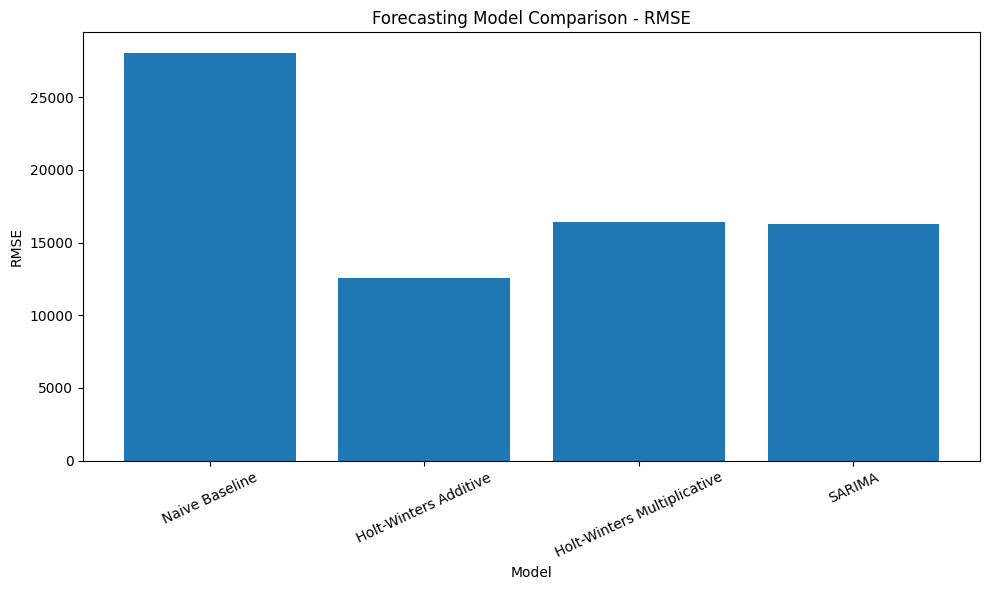

In [50]:
##PLOTTING THE COMPARISONS
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.title("Forecasting Model Comparison - RMSE")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

In [51]:
##MACHINE LEARNING FORECASTING
ml_data = monthly_sales.copy()

In [52]:
##CREATING TIME BASED
ml_data["Year"] = ml_data["Date"].dt.year

ml_data["Month"] = ml_data["Date"].dt.month

ml_data["Quarter"] = ml_data["Date"].dt.quarter

In [53]:
##CREATING LAG FEATURES
ml_data["Lag_1"] = ml_data["Sales"].shift(1)

ml_data["Lag_2"] = ml_data["Sales"].shift(2)

ml_data["Lag_3"] = ml_data["Sales"].shift(3)

ml_data["Lag_6"] = ml_data["Sales"].shift(6)

ml_data["Lag_12"] = ml_data["Sales"].shift(12)

In [54]:
##CREATING ROLLING FEATURES
#NOW CALCULATING RECENT SALES AVERAGE
ml_data["Rolling_Mean_3"] = (
    ml_data["Sales"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

ml_data["Rolling_Mean_6"] = (
    ml_data["Sales"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

ml_data["Rolling_Mean_12"] = (
    ml_data["Sales"]
    .shift(1)
    .rolling(window=12)
    .mean()
)

In [ ]:
##FIRST 15 ROWS OF THE MACHINE LEARNING DATASET
ml_data.head(15)

In [56]:
##REMOVING NULL VALUES
ml_data = ml_data.dropna().reset_index(drop=True)

In [ ]:
##FIRST FEW ROWS OF THE CLEANED MACHINE LEARNING DATASET
ml_data.head()

In [58]:
##DEFINING FEATURES AND TARGET VARIABLE
features = [
    "Year",
    "Month",
    "Quarter",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_6",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_6",
    "Rolling_Mean_12"
]
target = "Sales"

In [59]:
##SPLITTING DATA
ml_train = ml_data.iloc[:-12].copy()

ml_test = ml_data.iloc[-12:].copy()

In [60]:
X_train = ml_train[features]

y_train = ml_train[target]

X_test = ml_test[features]

y_test = ml_test[target]

In [ ]:
print("Training rows:", len(X_train))

print("Testing rows:", len(X_test))

In [81]:
##NOW BUILDING A MACHINE LEARNING MODEL
from sklearn.ensemble import RandomForestRegressor

In [67]:
##CREATING RANDOM FOREST MODEL
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    min_samples_leaf=2
)

In [ ]:
##TRAINING THE MODEL
rf_model.fit(
    X_train,
    y_train
)

In [69]:
##MAKING PREDICTIONS ON THE TEST DATA
rf_predictions = rf_model.predict(
    X_test
)


In [ ]:
##EVALUATING RANDOM FOREST MODEL PERFORMANCE
mae_rf = mean_absolute_error(
    y_test,
    rf_predictions
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

mape_rf = mean_absolute_percentage_error(
    y_test,
    rf_predictions
)

print("Random Forest MAE:", mae_rf)

print("Random Forest RMSE:", rmse_rf)

print("Random Forest MAPE:", mape_rf)

In [ ]:
##ADDING RANDOM FOREST TO MY COMPARISON TABLE
final_comparison = pd.DataFrame({

    "Model": [
        "Naive Baseline",
        "Holt-Winters Additive",
        "Holt-Winters Multiplicative",
        "SARIMA",
        "Random Forest"
    ],

    "MAE": [
        mae_baseline,
        mae_additive,
        mae_multiplicative,
        mae_sarima,
        mae_rf
    ],

    "RMSE": [
        rmse_baseline,
        rmse_additive,
        rmse_multiplicative,
        rmse_sarima,
        rmse_rf
    ],

    "MAPE": [
        mean_absolute_percentage_error(
            test_series,
            baseline_predictions
        ),

        mean_absolute_percentage_error(
            test_series,
            pred_additive
        ),

        mean_absolute_percentage_error(
            test_series,
            pred_multiplicative
        ),

        mape_sarima,

        mape_rf
    ]
})

final_comparison.sort_values(
    "RMSE",
)

In [ ]:
##IMPORTANT FEATURES IN THE RANDOM FOREST MODEL
feature_importance = pd.DataFrame({

    "Feature": features,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

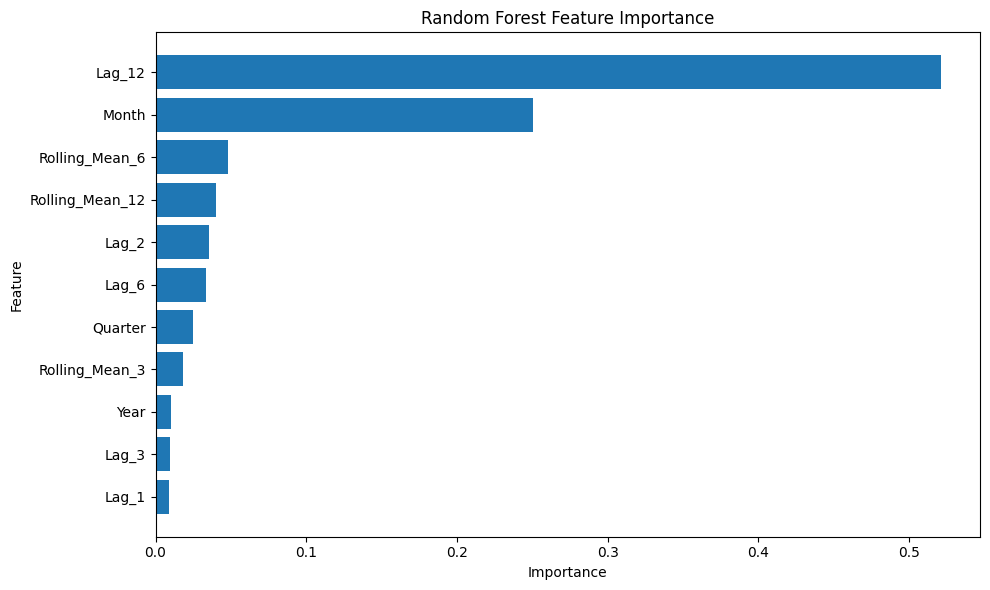

In [75]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### The important conclusion

Holt-Winters Additive is currently our best model.

It has the lowest:

MAE
RMSE

The multiplicative model has the lowest MAPE, but its MAE and RMSE are worse.

Therefore, for the main forecasting model, I would select:

Holt-Winters Additive

This is a very good result because we didn't decide the winner beforehand. We tested multiple approaches and selected the model based on unseen test data.


The Random Forest model improved substantially over the naive baseline, indicating that the engineered temporal and lag features contained useful predictive information. However, its performance remained inferior to the additive Holt-Winters model, suggesting that the statistical time-series model captured the underlying temporal structure more effectively for this dataset

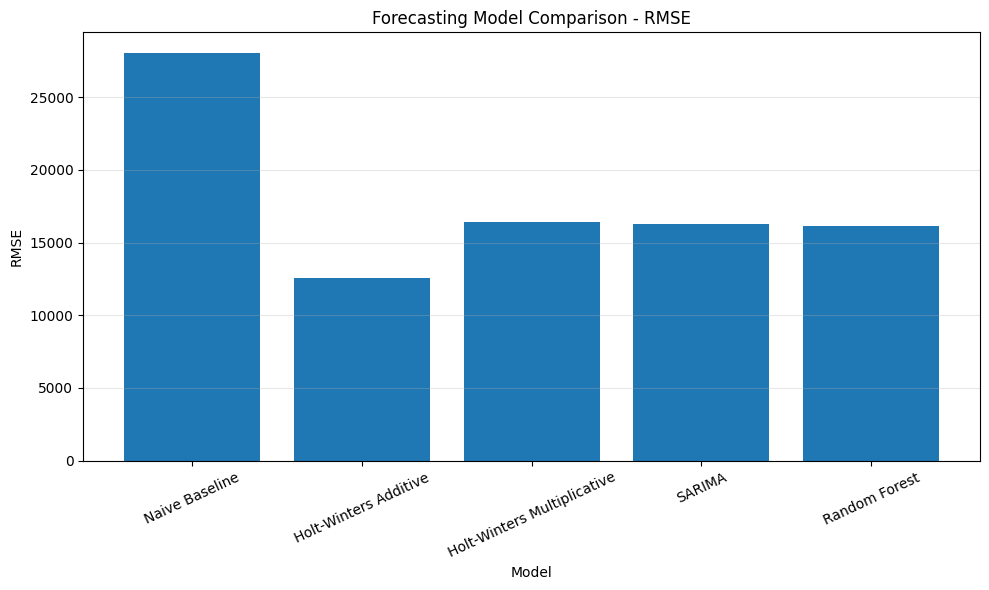

In [76]:
##RMSE COMPARISON PLOT
plt.figure(figsize=(10, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["RMSE"]
)

plt.title("Forecasting Model Comparison - RMSE")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.xticks(rotation=25)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

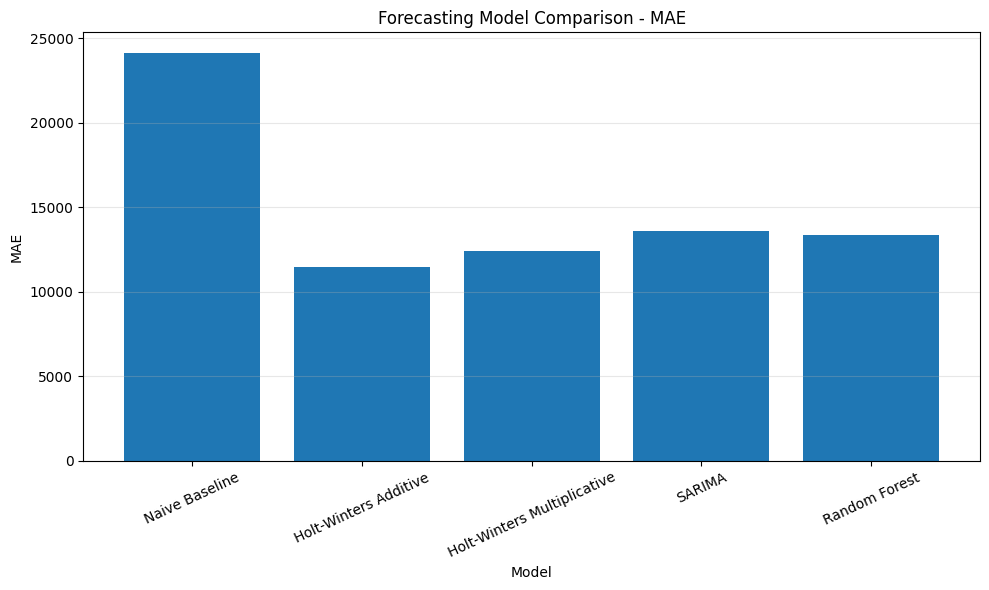

In [77]:
##
plt.figure(figsize=(10, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["MAE"]
)

plt.title("Forecasting Model Comparison - MAE")

plt.xlabel("Model")

plt.ylabel("MAE")

plt.xticks(rotation=25)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [78]:
##FINAL FORECASTING MODEL
final_series = monthly_sales.set_index("Date")["Sales"]

In [ ]:
final_model = ExponentialSmoothing(
    final_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit(
    optimized=True
)

In [80]:
##GENERATING A FUTURE 12 MONTH FUTURE FORECAST
future_forecast = final_model.forecast(
    steps=12
)

In [ ]:
##VIEWING THE FUTURE FORECAST
future_forecast

In [82]:
##PUTTING THE HISTORICAL DATA AND FUTURE FORECAST TOGETHER
forecast_df = future_forecast.reset_index()

In [83]:
forecast_df.columns = [
    "Date",
    "Forecast_Sales"
]

In [ ]:
forecast_df

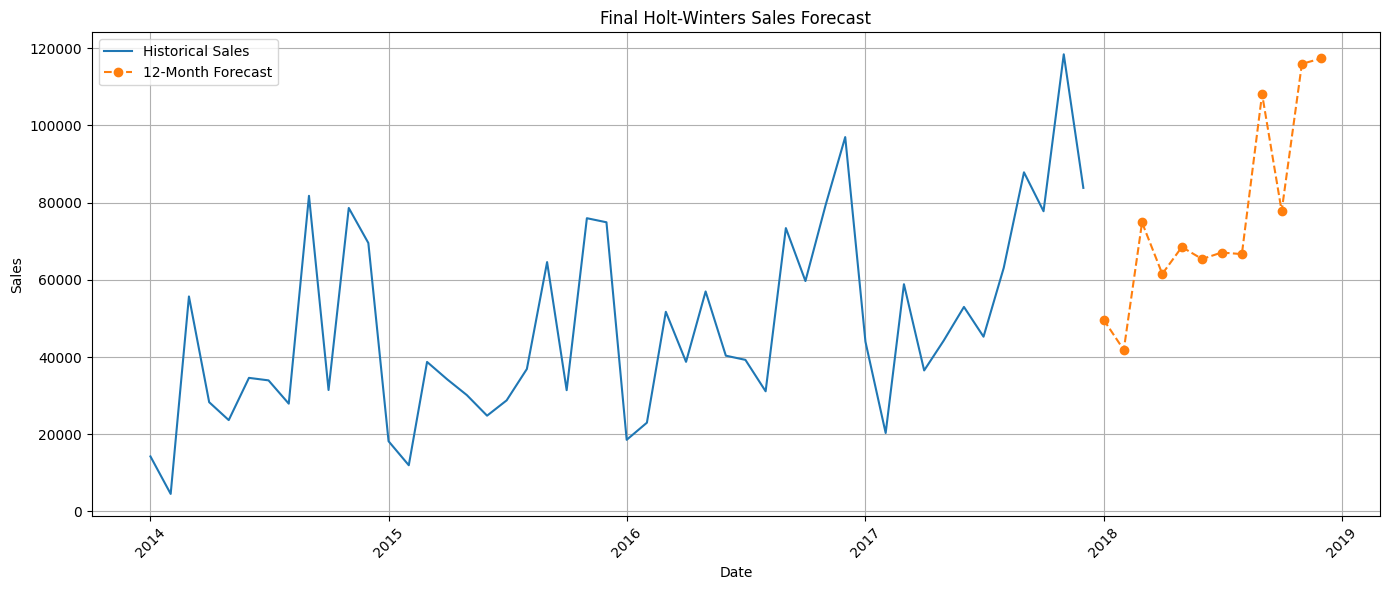

In [85]:
##PLOTTING THE FINAL FORECAST
plt.figure(figsize=(14, 6))

plt.plot(
    final_series.index,
    final_series,
    label="Historical Sales"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast_Sales"],
    marker="o",
    linestyle="--",
    label="12-Month Forecast"
)

plt.title(
    "Final Holt-Winters Sales Forecast"
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
##CALCULATE THE EXPECTED TOTAL FORECAST SALES
##DASHBOARD KPI
total_forecast_sales = future_forecast.sum()

print(
    "Total Forecasted Sales:",
    total_forecast_sales
)

In [ ]:
##CALCULATING THE AVERAGE
average_forecast_sales = future_forecast.mean()

print(
    "Average Monthly Forecast:",
    average_forecast_sales
)

In [ ]:
##HIGHEST FORECAST MONTH
highest_forecast_month = future_forecast.idxmax()

highest_forecast_value = future_forecast.max()

print(
    "Highest Forecast Month:",
    highest_forecast_month
)

print(
    "Highest Forecast Sales:",
    highest_forecast_value
)

In [ ]:
## 9. Final Forecast Results and Dashboard Data
# ------------------------------------------------------------
# 1. Generate 12-month future forecast
# ------------------------------------------------------------

forecast_values = final_model.forecast(steps=12)

# Build a clean DataFrame for dashboard use
forecast_index = pd.date_range(
    start=final_series.index[-1] + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": forecast_index,
    "Forecast_Sales": forecast_values.values
})

forecast_df

In [94]:
# ------------------------------------------------------------
# 1. Generate 12-month future forecast
# ------------------------------------------------------------

forecast_values = final_model.forecast(steps=12)

# Make sure the forecast has a proper DateTime index
forecast_values.index = pd.to_datetime(forecast_values.index)

In [95]:
# ------------------------------------------------------------
# 2. Create forecast DataFrame
# ------------------------------------------------------------

forecast_df = pd.DataFrame({
    "Date": forecast_values.index,
    "Forecast_Sales": forecast_values.values
})

In [96]:
# ------------------------------------------------------------
# 3. Calculate forecast KPIs
# ------------------------------------------------------------

total_forecast_sales = forecast_df["Forecast_Sales"].sum()

average_forecast_sales = forecast_df["Forecast_Sales"].mean()

highest_forecast_index = forecast_df["Forecast_Sales"].idxmax()

highest_forecast_month = forecast_df.loc[
    highest_forecast_index, "Date"
]

highest_forecast_value = forecast_df.loc[
    highest_forecast_index, "Forecast_Sales"
]

lowest_forecast_index = forecast_df["Forecast_Sales"].idxmin()

lowest_forecast_month = forecast_df.loc[
    lowest_forecast_index, "Date"
]

lowest_forecast_value = forecast_df.loc[
    lowest_forecast_index, "Forecast_Sales"
]

In [ ]:
# ------------------------------------------------------------
# 4. Print final forecast KPIs
# ------------------------------------------------------------

print("=" * 60)
print("FINAL SALES FORECAST RESULTS")
print("=" * 60)

print(
    f"Total Forecasted Sales: "
    f"${total_forecast_sales:,.2f}"
)

print(
    f"Average Monthly Forecast: "
    f"${average_forecast_sales:,.2f}"
)

print(
    f"Highest Forecast Month: "
    f"{highest_forecast_month.strftime('%B %Y')}"
)

print(
    f"Highest Forecast Value: "
    f"${highest_forecast_value:,.2f}"
)

print(
    f"Lowest Forecast Month: "
    f"{lowest_forecast_month.strftime('%B %Y')}"
)

print(
    f"Lowest Forecast Value: "
    f"${lowest_forecast_value:,.2f}"
)

print(
    f"Forecast Period: "
    f"{forecast_df['Date'].min().strftime('%B %Y')} "
    f"to "
    f"{forecast_df['Date'].max().strftime('%B %Y')}"
)

print(
    f"Number of Forecast Months: "
    f"{len(forecast_df)}"
)


In [ ]:
# ------------------------------------------------------------
# 5. Displaying incomplete forecast table
# ------------------------------------------------------------

print("\nFORECAST TABLE")
print("=" * 60)

display(
    forecast_df.style.format({
        "Forecast_Sales": "${:,.2f}"
    })
)


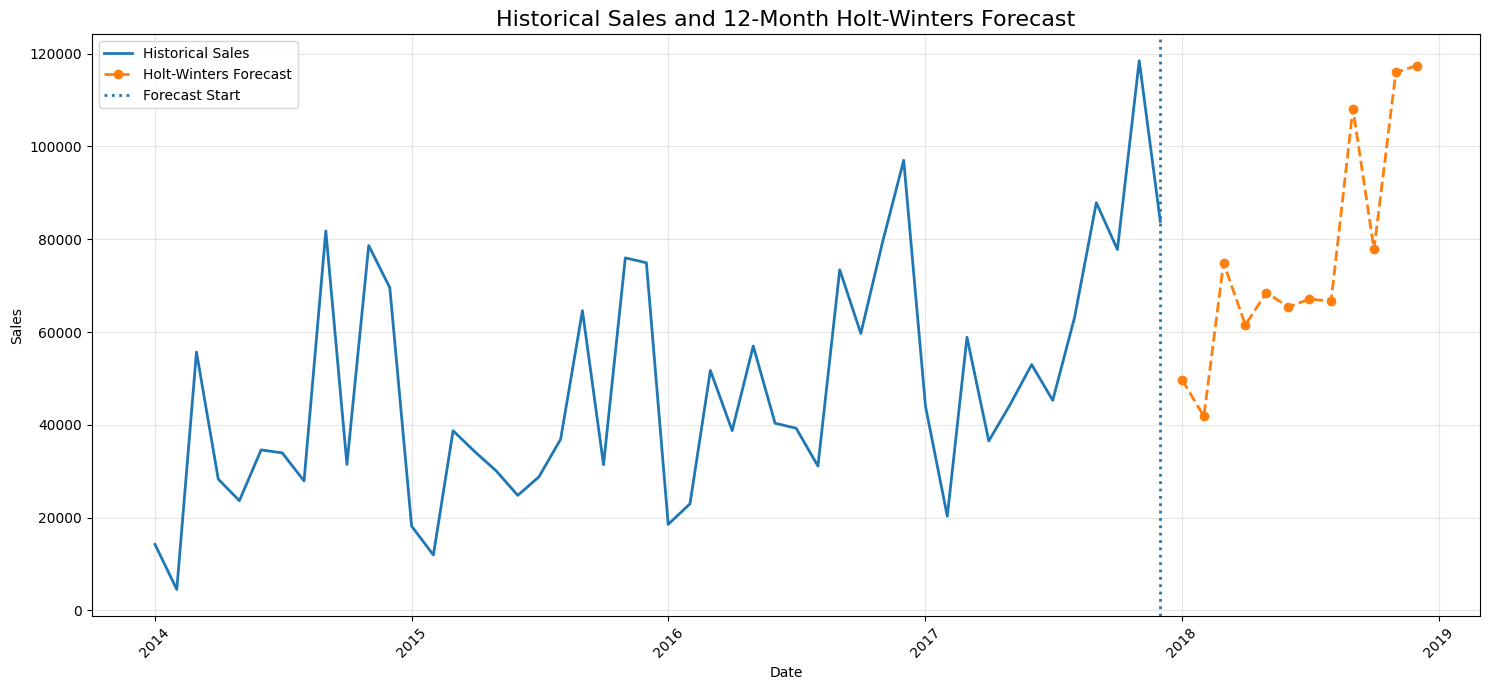

In [ ]:
# ------------------------------------------------------------
# 6. Plotting historical sales + future forecast
# ------------------------------------------------------------

plt.figure(figsize=(15, 7))

# Historical sales
plt.plot(
    final_series.index,
    final_series.values,
    label="Historical Sales",
    linewidth=2
)

# Forecast
plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast_Sales"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Holt-Winters Forecast"
)


plt.axvline(
    x=final_series.index[-1],
    linestyle=":",
    linewidth=2,
    label="Forecast Start"
)

plt.title(
    "Historical Sales and 12-Month Holt-Winters Forecast",
    fontsize=16
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
# ------------------------------------------------------------
# 7. Creating dashboard-ready KPI dictionary
# ------------------------------------------------------------

forecast_kpis = {
    "total_forecast_sales": total_forecast_sales,
    "average_monthly_forecast": average_forecast_sales,
    "highest_forecast_month": highest_forecast_month,
    "highest_forecast_sales": highest_forecast_value,
    "lowest_forecast_month": lowest_forecast_month,
    "lowest_forecast_sales": lowest_forecast_value,
    "forecast_months": len(forecast_df)
}


In [ ]:
# ------------------------------------------------------------
# 8. Final confirmation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DASHBOARD DATA READY")
print("=" * 60)

print(
    "Forecast DataFrame shape:",
    forecast_df.shape
)

print(
    "Forecast KPI information:"
)

print(forecast_kpis)

In [ ]:
##CHECKING FORECAST DATAFRAME AND KPI DICTIONARY
print(forecast_df)

print("\n")

print(forecast_kpis)

In [129]:
##SAVING FORECAST DATAFRAME AND KPI DICTIONARY FOR DASHBOARD
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

forecast_df.to_csv(
    output_dir / "forecast_df.csv",
    index=False
)

FINAL MODEL VALIDATION

In [ ]:
# ============================================================
# 1. PREPARING THE MONTHLY SALES SERIES
# ============================================================

# Make sure the sales series has a DateTime index
monthly_sales = final_series.copy()

monthly_sales.index = pd.to_datetime(
    monthly_sales.index
)

monthly_sales = monthly_sales.sort_index()

In [ ]:
# ============================================================
# 2. CREATING TRAIN / TEST SPLIT
# ============================================================

# Use the same 36 training observations
# and 12 testing observations used earlier.

train_size = 36

train = monthly_sales.iloc[:train_size]

test = monthly_sales.iloc[train_size:]


print("=" * 60)
print("TRAIN / TEST DATA")
print("=" * 60)

print("Training observations:", len(train))
print("Testing observations:", len(test))

print(
    "Training period:",
    train.index.min().strftime("%B %Y"),
    "to",
    train.index.max().strftime("%B %Y")
)

print(
    "Testing period:",
    test.index.min().strftime("%B %Y"),
    "to",
    test.index.max().strftime("%B %Y")
)



In [ ]:
# ============================================================
# 3. FITTING HOLT-WINTERS ADDITIVE MODEL ON TRAINING DATA
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing

validation_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

In [ ]:
# ============================================================
# 4. GENERATING TEST-PERIOD PREDICTIONS
# ============================================================

test_predictions = validation_model.forecast(
    steps=len(test)
)

# Match prediction index to actual test index
test_predictions.index = test.index

In [ ]:
# ============================================================
# 5. CALCULATING MODEL PERFORMANCE METRICS
# ============================================================

mae = mean_absolute_error(
    test,
    test_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        test_predictions
    )
)


non_zero_actuals = test != 0

mape = np.mean(
    np.abs(
        (
            test[non_zero_actuals]
            -
            test_predictions[non_zero_actuals]
        )
        /
        test[non_zero_actuals]
    )
) * 100


In [ ]:
# ============================================================
# 6. CALCULATING RESIDUALS
# ============================================================

residuals = (
    test
    -
    test_predictions
)

In [116]:
# ============================================================
# 7. RESIDUAL STATISTICS
# ============================================================

mean_residual = residuals.mean()

std_residual = residuals.std()

max_positive_error = residuals.max()

max_negative_error = residuals.min()

In [119]:
# ============================================================
# 8. BASELINE COMPARISON
# ============================================================

# Naive baseline:
# each prediction equals the previous observed value

baseline_predictions = train.iloc[-1]

baseline_predictions = pd.Series(
    baseline_predictions,
    index=test.index
)

baseline_mae = mean_absolute_error(
    test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test,
        baseline_predictions
    )
)


# Calculate improvement over baseline

mae_improvement = (
    (baseline_mae - mae)
    /
    baseline_mae
) * 100


rmse_improvement = (
    (baseline_rmse - rmse)
    /
    baseline_rmse
) * 100


In [ ]:
# ============================================================
# 9. PRINTING FINAL MODEL PERFORMANCE
# ============================================================

print("\n")
print("=" * 60)
print("FINAL HOLT-WINTERS MODEL PERFORMANCE")
print("=" * 60)

print(
    f"MAE:  ${mae:,.2f}"
)

print(
    f"RMSE: ${rmse:,.2f}"
)

print(
    f"MAPE: {mape:.2f}%"
)


print("\n")
print("=" * 60)
print("BASELINE COMPARISON")
print("=" * 60)

print(
    f"Baseline MAE:  ${baseline_mae:,.2f}"
)

print(
    f"Holt-Winters MAE: ${mae:,.2f}"
)

print(
    f"MAE Improvement: {mae_improvement:.2f}%"
)


print(
    f"\nBaseline RMSE: ${baseline_rmse:,.2f}"
)

print(
    f"Holt-Winters RMSE: ${rmse:,.2f}"
)

print(
    f"RMSE Improvement: {rmse_improvement:.2f}%"
)

In [ ]:
# ============================================================
# 10. SAVE MODEL VALIDATION RESULTS FOR DASHBOARD
# ============================================================

model_validation_df = pd.DataFrame({
    "Date": test.index,
    "Actual_Sales": test.values,
    "Predicted_Sales": test_predictions.values,
    "Error": residuals.values
})

validation_output_dir = Path("../data/processed")
validation_output_dir.mkdir(parents=True, exist_ok=True)

model_validation_df.to_csv(
    validation_output_dir / "model_validation.csv",
    index=False
)

print("Saved model_validation.csv:", model_validation_df.shape)

In [ ]:
# ============================================================
# 10. ACTUAL VS PREDICTED TABLE
# ============================================================

validation_df = pd.DataFrame({

    "Date": test.index,

    "Actual_Sales": test.values,

    "Predicted_Sales": test_predictions.values

})

validation_df["Error"] = (
    validation_df["Actual_Sales"]
    -
    validation_df["Predicted_Sales"]
)

validation_df["Absolute_Error"] = (
    validation_df["Error"].abs()
)

validation_df["Percentage_Error"] = (
    validation_df["Absolute_Error"]
    /
    validation_df["Actual_Sales"].replace(0, np.nan)
) * 100


print("\n")
print("=" * 60)
print("ACTUAL VS PREDICTED SALES")
print("=" * 60)

display(
    validation_df.style.format({

        "Actual_Sales": "${:,.2f}",

        "Predicted_Sales": "${:,.2f}",

        "Error": "${:,.2f}",

        "Absolute_Error": "${:,.2f}",

        "Percentage_Error": "{:.2f}%"

    })
)


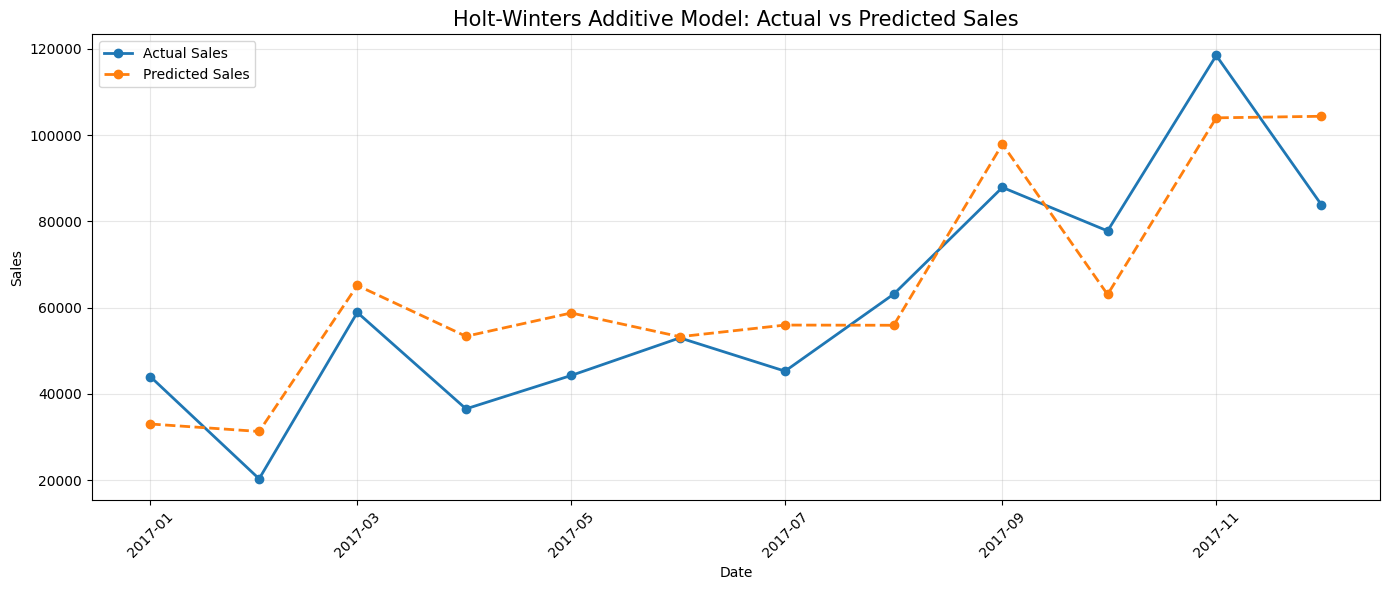

In [123]:
# ============================================================
# 11. ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    validation_df["Date"],
    validation_df["Actual_Sales"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    validation_df["Date"],
    validation_df["Predicted_Sales"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted Sales"
)

plt.title(
    "Holt-Winters Additive Model: Actual vs Predicted Sales",
    fontsize=15
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

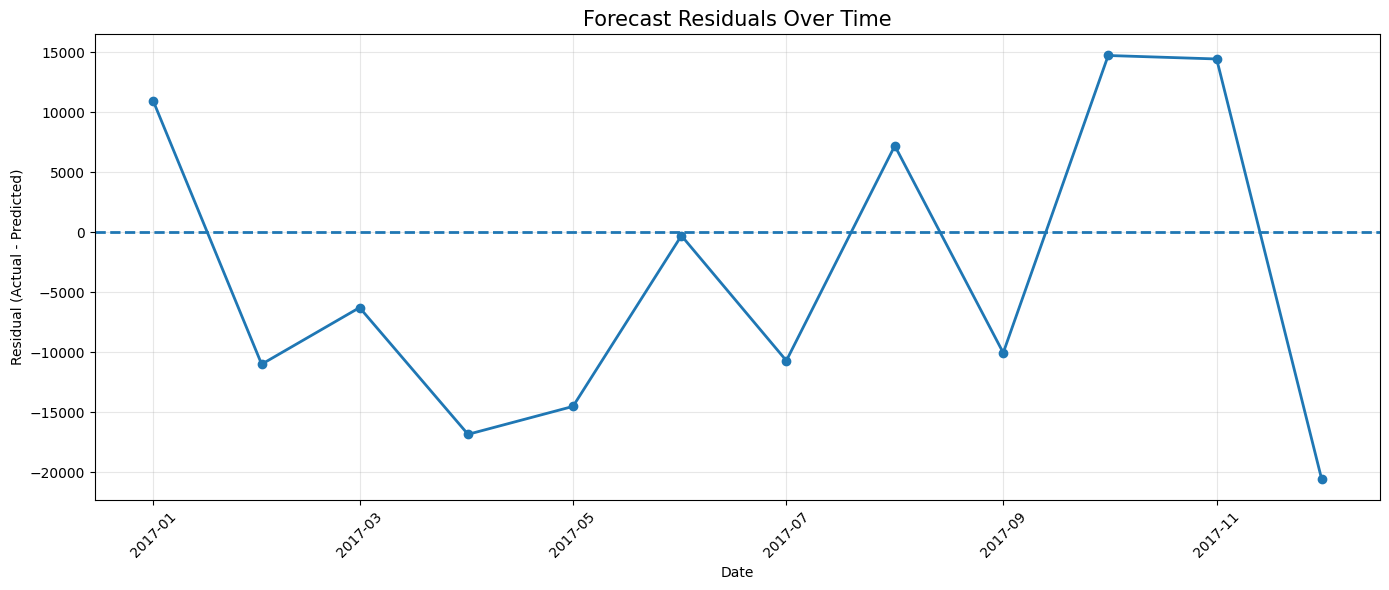

In [124]:
# ============================================================
# 12. RESIDUALS OVER TIME
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    validation_df["Date"],
    validation_df["Error"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Forecast Residuals Over Time",
    fontsize=15
)

plt.xlabel("Date")

plt.ylabel("Residual (Actual - Predicted)")

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

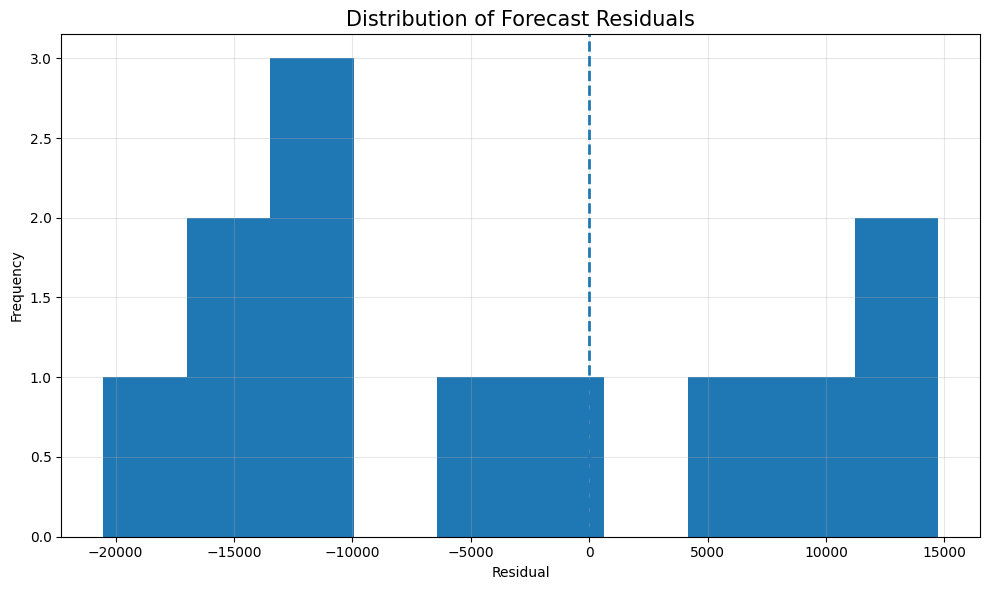

In [125]:
# ============================================================
# 13. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=10
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Distribution of Forecast Residuals",
    fontsize=15
)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 14. FINAL VALIDATION SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("FINAL VALIDATION SUMMARY")
print("=" * 60)

print(
    "Selected Model: Holt-Winters Additive"
)

print(
    f"MAE: ${mae:,.2f}"
)

print(
    f"RMSE: ${rmse:,.2f}"
)

print(
    f"MAPE: {mape:.2f}%"
)

print(
    f"Baseline RMSE: ${baseline_rmse:,.2f}"
)

print(
    f"RMSE Improvement over Baseline: "
    f"{rmse_improvement:.2f}%"
)

print(
    f"Mean Residual: ${mean_residual:,.2f}"
)

print(
    f"Residual Standard Deviation: "
    f"${std_residual:,.2f}"
)

print(
    f"Maximum Positive Error: "
    f"${max_positive_error:,.2f}"
)

print(
    f"Maximum Negative Error: "
    f"${max_negative_error:,.2f}"
)

### Mean residual of:

-$3,557.97

suggests that, on average, the model has a tendency to overpredict sales during the test period.

We should not hide this in the report. In fact, identifying this is exactly what makes the project look more like a genuine data-science investigation.

Maximum errors also show
Your largest positive error was:

+$14,740.80

while the largest negative error was:

-$20,527.69

This means the model's largest overprediction was larger in magnitude than its largest underprediction.

So we should investigate which months produced those errors.

In [ ]:
##MONTHS THAT PRODUCED THE ERRORS
# ============================================================
# ERROR ANALYSIS
# ============================================================

print("=" * 60)
print("LARGEST FORECAST ERRORS")
print("=" * 60)

# Largest overprediction
largest_overprediction = validation_df.loc[
    validation_df["Error"].idxmin()
]

# Largest underprediction
largest_underprediction = validation_df.loc[
    validation_df["Error"].idxmax()
]


print("\nLargest Overprediction:")
print(
    "Date:",
    largest_overprediction["Date"].strftime("%B %Y")
)
print(
    "Actual Sales:",
    f"${largest_overprediction['Actual_Sales']:,.2f}"
)
print(
    "Predicted Sales:",
    f"${largest_overprediction['Predicted_Sales']:,.2f}"
)
print(
    "Error:",
    f"${largest_overprediction['Error']:,.2f}"
)


print("\nLargest Underprediction:")
print(
    "Date:",
    largest_underprediction["Date"].strftime("%B %Y")
)
print(
    "Actual Sales:",
    f"${largest_underprediction['Actual_Sales']:,.2f}"
)
print(
    "Predicted Sales:",
    f"${largest_underprediction['Predicted_Sales']:,.2f}"
)
print(
    "Error:",
    f"${largest_underprediction['Error']:,.2f}"
)

In [ ]:
##RESIDUAL PATTERN
# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

print("=" * 60)
print("RESIDUAL ANALYSIS")
print("=" * 60)

print(
    "Mean Residual:",
    f"${residuals.mean():,.2f}"
)

print(
    "Median Residual:",
    f"${residuals.median():,.2f}"
)

print(
    "Standard Deviation:",
    f"${residuals.std():,.2f}"
)

print(
    "Minimum Residual:",
    f"${residuals.min():,.2f}"
)

print(
    "Maximum Residual:",
    f"${residuals.max():,.2f}"
)


# Count positive and negative residuals

positive_errors = (residuals > 0).sum()
negative_errors = (residuals < 0).sum()

print(
    "\nUnderpredicted months:",
    positive_errors
)

print(
    "Overpredicted months:",
    negative_errors
)

### Model Validation

The Holt-Winters Additive model was evaluated using a holdout test dataset. The model achieved a Mean Absolute Error (MAE) of $11,453.22, a Root Mean Squared Error (RMSE) of $12,541.24, and a Mean Absolute Percentage Error (MAPE) of 22.59%.

When compared with the baseline model, which produced an MAE of $39,472.57 and an RMSE of $44,191.89, the Holt-Winters model demonstrated substantial improvement. MAE decreased by 70.98%, while RMSE decreased by 71.62%.

These results indicate that the Holt-Winters Additive model was considerably more effective than the baseline at forecasting monthly sales during the test period.

However, the residual analysis indicates a mean residual of -$3,557.97, suggesting a tendency toward overprediction during the validation period. The maximum positive error was $14,740.80, while the maximum negative error was -$20,527.69. These errors should be considered when interpreting the model's future predictions.

So basically:

The largest forecasting error occurred in December 2017, when the model overpredicted sales by approximately $20,527.69. The largest underprediction occurred in October 2017, where actual sales exceeded predicted sales by approximately $14,740.80.